# Linear Regression Using Gradient Descent

> Implementation of a gradient descent on the mean squared error using numpy


- GD is an optimization algorithm
- The gradient of a funciton is defined by its (partial) derivative
- GD uses iterations to minimize the slope of the functions that it minimizes

In [47]:
import numpy as np
import random
import seaborn as sns
from matplotlib import pyplot as plt

Mean Squared Error of the straight line: 2067.6179545553446


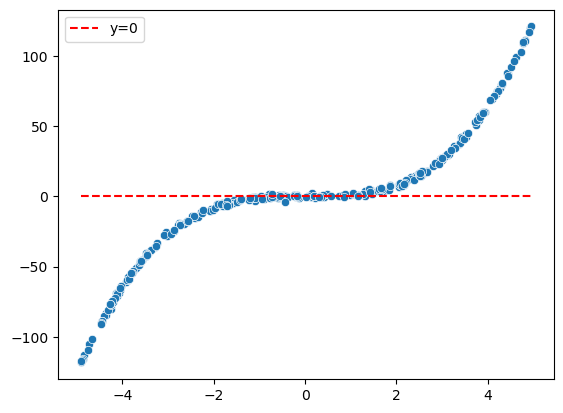

In [52]:
# generating some sample data
size = 300
X = np.random.uniform(-5, 5, size=size)
x = X
y = x**3 + np.random.normal(0, 1, size=size)

# baseline
mse_straight_line = np.mean((y - 0)**2)
print(f"Mean Squared Error of the straight line: {mse_straight_line}")

# plotting the data
sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=0, color="red", linestyle="--", label="y=0")
plt.show()


MSE and its derivative

${MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$

$\frac{df}{dx}MSE = -2\sum_{i=1}^{n}(y- \hat{y})$

In [49]:
def LR_GD(x, y, learning_rate=0.1, max_epoch=100):
    '''
    finding minimum mean square error using gradient descent
    x = np.array | x-scatter values
    y = np.array | y-scatter values
    '''
    epoch = 0
    
    # random initial values
    m = random.uniform(-1, 1)
    b = random.uniform(-1, 1)
      
    print(f'initial parameters: m={m}, b={b}')
    
    while max_epoch > epoch:
        # predicted value for each iteration
        y_hat = m * x + b
        # Calculate gradients (plug into derivative of MSE)
        m_gradient = -2 * np.mean(x * (y - y_hat))
        b_gradient = -2 * np.mean(y - y_hat)
        
        has_converged = abs(m_gradient) < 0.01 and abs(b_gradient) < 0.01
        if has_converged:
            print(f"Converged at epoch {epoch}")
            break
        else:
            # Update parameters
            m = m - learning_rate * m_gradient
            b = b - learning_rate * b_gradient
          
        print(f"epoch: {epoch}, m: {m:.4f}, b: {b:.4f}")
            
        epoch += 1
    
    return m, b, y_hat

LR_m, LR_b, LR_pred = LR_GD(x, y)




initial parameters: m=-0.6040691251276074, b=-0.47659725718447565
epoch: 0, m: 22.9731, b: 0.8293
epoch: 1, m: 9.3861, b: 0.0730
epoch: 2, m: 17.2162, b: 0.5059
epoch: 3, m: 12.7040, b: 0.2541
epoch: 4, m: 15.3044, b: 0.3973
epoch: 5, m: 13.8059, b: 0.3132
epoch: 6, m: 14.6696, b: 0.3604
epoch: 7, m: 14.1719, b: 0.3322
epoch: 8, m: 14.4587, b: 0.3477
epoch: 9, m: 14.2935, b: 0.3381
epoch: 10, m: 14.3888, b: 0.3431
epoch: 11, m: 14.3339, b: 0.3398
epoch: 12, m: 14.3655, b: 0.3414
epoch: 13, m: 14.3473, b: 0.3402
epoch: 14, m: 14.3578, b: 0.3407
epoch: 15, m: 14.3518, b: 0.3402
epoch: 16, m: 14.3553, b: 0.3403
epoch: 17, m: 14.3532, b: 0.3402
epoch: 18, m: 14.3544, b: 0.3402
Converged at epoch 19


Mean Square Error: 323.79366106373857


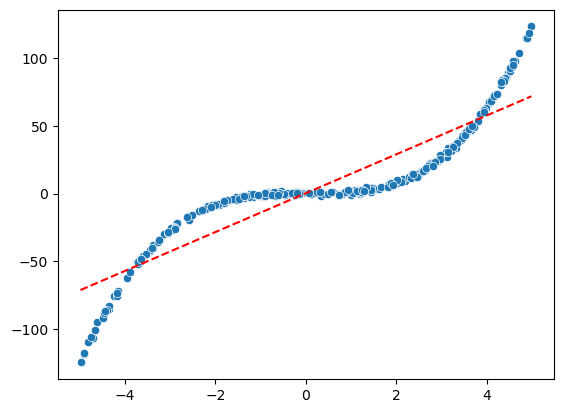

In [50]:
# Evaluation

mse = np.mean((y - LR_pred) ** 2)
print(f'Mean Square Error: {mse}')

sns.scatterplot(x=x, y=y)
sns.lineplot(x=x, y=LR_pred, color='red', linestyle='--')
plt.show()